# Diffusion from random motion

**Numerical methods project | Random walks and differential equations based on MMP-II coursework** 

*This is a compilation of warm-up excercises done for an internship project. Placed here as this is based on random-walk methods from my Mathematical Methods for Physicists-II coursework.*

Suppose many particles are released at $x=0$. Each particle independently moves one unit left or right per time step. What does their distribution look like later, and how quickly does it spread?

We will simulate the particles, measure their distribution, and compare with the one-dimensional diffusion equation. This is a simple discrete model: particles take fixed-length steps, while the diffusion equation describes the smooth distribution at larger scales.


In [13]:
import numpy as np
import matplotlib.pyplot as plt

# A fixed seed reproduces the random draws when cells run in order.
np.random.seed(17)

# Each particle is an independent realization of the same random walk.
number_of_particles = 5000
number_of_steps = 400

# Length and time units are arbitrary
step_length = 1
step_time = 1
if step_length <= 0 or step_time <= 0:
    raise ValueError('Step length and step time must be positive.')

# Fair steps have variance a^2 per step; diffusion has variance 2Dt.
# Matching them gives D = a^2 / (2 * step_time), with units length^2/time.
D = step_length ** 2 / (2 * step_time)
print('Diffusion coefficient D =', D)


Diffusion coefficient D = 0.5


## 1. Release the particles

**Task.** Start all particles at zero. At each time step, toss a fair coin for every particle and move it left or right. Store the positions at three chosen times.


In [14]:
positions = np.zeros(number_of_particles, dtype=float)
snapshots = {}
times_to_save = [20, 100, 400]
widths = [0] # At the initial time every particle is at zero, so the width is zero.

# Here time is a STEP COUNT; physical elapsed time is time * step_time.
for time in range(1, number_of_steps + 1):
    for particle in range(number_of_particles):
        coin = np.random.randint(2)
        if coin == 0:
            positions[particle] = positions[particle] - step_length
        else:
            positions[particle] = positions[particle] + step_length
    
    # Standard deviation measures spread around the current sample mean.
    # This averages across particles, rather than along one trajectory.
    widths.append(np.std(positions))
    if time in times_to_save:
        # Copy freezes the snapshot; without it later moves would change the saved array.
        snapshots[time] = positions.copy()

print('Mean position after', number_of_steps, 'steps:', round(np.mean(positions), 2))

# Snapshot keys are step counts; physical elapsed time is count * step_time.
def lattice_bins(data, step_count):
    
    # Reachable sites are separated by 2 * step_length.
    # % 2 gives parity: even counts reach even multiples of a, odd counts odd multiples.
    offset = (step_count % 2) * step_length

    # Map positions to integer labels on the accessible lattice.
    indices = np.rint((np.asarray(data) - offset) / (2 * step_length)).astype(int)
    
    # Place edges one step length either side of the accessible sites.
    return offset + (2 * np.arange(indices.min(), indices.max() + 2) - 1) * step_length

# Use the same viewing range at all times to make spreading easy to compare.
plot_half_width = 3.25 * np.sqrt(2 * D * number_of_steps * step_time)


Mean position after 400 steps: -0.25


## 2. Watch the distribution spread

**Task.** Make a histogram at each saved time. We group positions into bins of width 2 because, after a fixed number of steps, the walker can reach only every other integer position. Used `density=True` so the histograms could be compared with probability density curves.


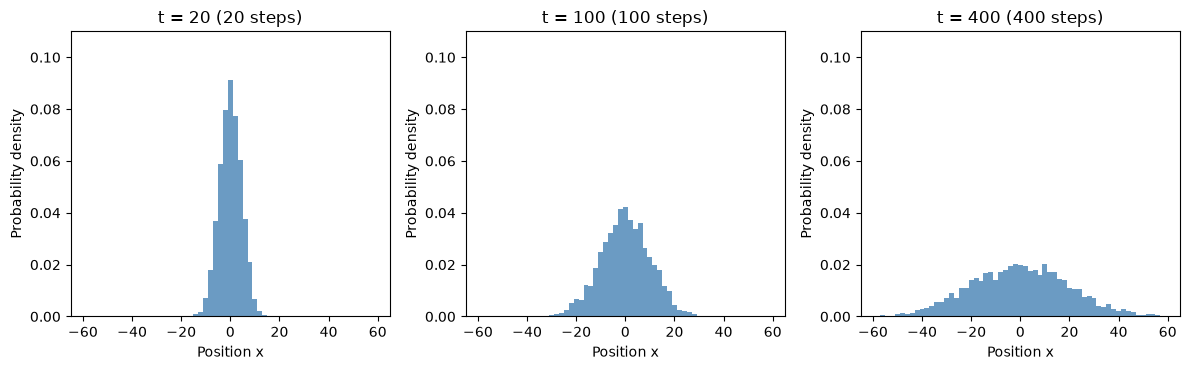

In [15]:
plt.figure(figsize=(12, 3.8))
for i, time in enumerate(times_to_save):
    data = snapshots[time]
    bins = lattice_bins(data, time)

    # Convert the snapshot label to physical time for the title.
    elapsed_time = time * step_time

    plt.subplot(1, 3, i + 1)

    # Density height = bin count / (particle number * bin width).
    plt.hist(data, bins=bins, density=True, color='steelblue', alpha=0.8)
    plt.xlim(-plot_half_width, plot_half_width)
    plt.ylim(0, 0.11 / step_length)
    plt.title('t = ' + str(elapsed_time) + ' (' + str(time) + ' steps)')
    plt.xlabel('Position x')
    plt.ylabel('Probability density')

plt.tight_layout()
plt.show()

The particles remain centered near the release point, while the distribution becomes wider and lower. A single particle follows an irregular path; the pattern appears when we count many particles.

## 3. Prediction from the diffusion equation

The probability density $p(x,t)$ obeys

$$\frac{\partial p}{\partial t}=D\frac{\partial^2 p}{\partial x^2}.$$

For particles released at $x=0$ on an unbounded line, its solution is

$$p(x,t)=\frac{1}{\sqrt{4\pi Dt}}\exp\left(-\frac{x^2}{4Dt}\right).$$

This curve has mean zero and standard deviation

$$\sigma(t)=\sqrt{2Dt}.$$

For steps of length 1 taken every 1 time unit, $D=1/2$, so the predicted width is $\sqrt{t}$. The smooth curve is an approximation to the discrete walk, especially at later times.


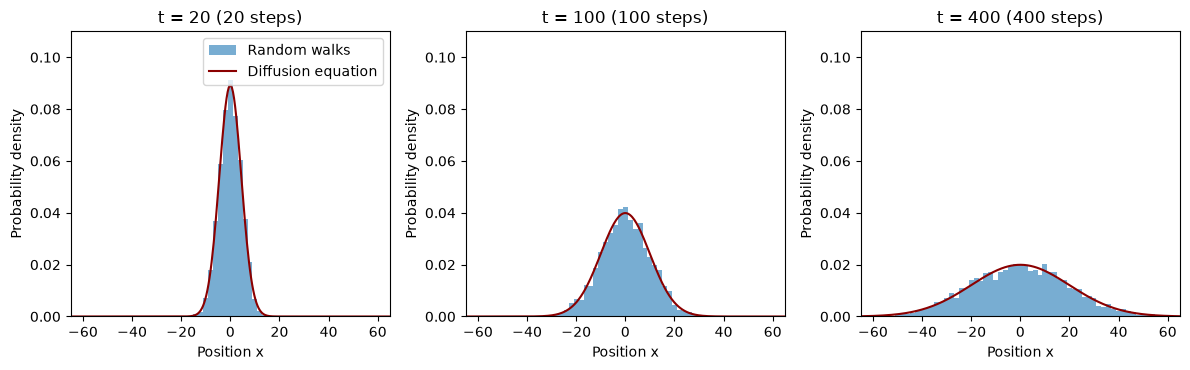

In [16]:
plt.figure(figsize=(12, 3.8))
for i, time in enumerate(times_to_save):
    data = snapshots[time]
    bins = lattice_bins(data, time)
    elapsed_time = time * step_time

    # A fine set of x values makes a smooth analytic curve, independent of particle sites.
    x_values = np.linspace(-plot_half_width, plot_half_width, 300)

    # Infinite-line diffusion solution for a point release at x = 0.
    # The denominator normalizes its integral to 1; variance is 2D * elapsed_time.
    prediction = np.exp(-x_values ** 2 / (4 * D * elapsed_time)) / np.sqrt(4 * np.pi * D * elapsed_time)

    plt.subplot(1, 3, i + 1)
    plt.hist(data, bins=bins, density=True, alpha=0.6, label='Random walks')
    plt.plot(x_values, prediction, color='darkred', label='Diffusion equation')
    plt.xlim(-plot_half_width, plot_half_width)
    plt.ylim(0, 0.11 / step_length)
    plt.title('t = ' + str(elapsed_time) + ' (' + str(time) + ' steps)')
    plt.xlabel('Position x')
    plt.ylabel('Probability density')
    if i == 0:
        plt.legend()

plt.tight_layout()
plt.show()


## 4. Check the width over time

**Task.** Measure the standard deviation of particle positions after every step. Compare it with $\sqrt{2Dt}$. The square of the width is the **variance**, $\mathrm{Var}(X)=\langle X^2\rangle-\langle X\rangle^2$, and should grow linearly with physical time. It equals the theoretical raw mean squared displacement only when the theoretical mean is zero. For a finite sample the squared sample mean accounts for their difference; with drift the distinction is substantial.


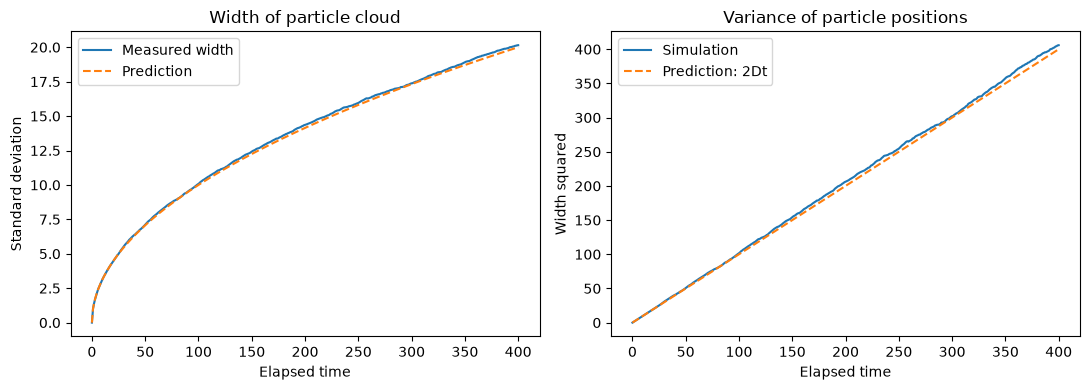

t = 20 | measured width = 4.46 | predicted width = 4.47
t = 100 | measured width = 10.08 | predicted width = 10.0
t = 400 | measured width = 20.15 | predicted width = 20.0


In [17]:
# Include the initial instant and convert all step counts to elapsed time.
time = np.arange(number_of_steps + 1) * step_time

# Diffusion predicts standard deviation sqrt(2Dt), not a width linear in time.
predicted_width = np.sqrt(2 * D * time)

plt.figure(figsize=(11, 4))
plt.subplot(1, 2, 1)
plt.plot(time, widths, label='Measured width')
plt.plot(time, predicted_width, '--', label='Prediction')
plt.xlabel('Elapsed time')
plt.ylabel('Standard deviation')
plt.title('Width of particle cloud')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(time, np.array(widths) ** 2, label='Simulation')
plt.plot(time, 2 * D * time, '--', label='Prediction: 2Dt')
plt.xlabel('Elapsed time')
plt.ylabel('Width squared')
plt.title('Variance of particle positions')
plt.legend()
plt.tight_layout()
plt.show()

for t in times_to_save:
    print('t =', t * step_time, '| measured width =', round(widths[t], 2),
          '| predicted width =', round(np.sqrt(2 * D * t * step_time), 2))


## 5. Solve the diffusion equation on a grid

**Task.** Use forward Euler in time and a centred second difference in space:

$$p_i^{n+1}=p_i^n+\frac{D\,\Delta t}{(\Delta x)^2}(p_{i+1}^n-2p_i^n+p_{i-1}^n).$$

Choose $\Delta x=a$ and target $\Delta t=0.4\Delta t_{\rm step}$. Adjust the time step slightly if necessary to reach the final particle time exactly. The stability condition is $0\leq D\Delta t/(\Delta x)^2\leq1/2$; the default factor is 0.2. The initial central density is $1/\Delta x$, so its integrated probability is one.


Grid calculation time: 400.0
Probability remaining on grid: 0.999999
Minimum grid density: 0.0


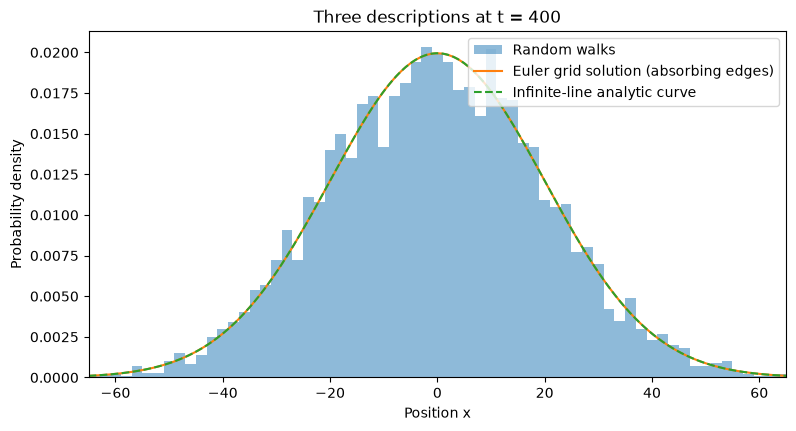

In [18]:
final_time = number_of_steps * step_time
final_width = np.sqrt(2 * D * final_time)
dx = step_length
half_grid = int(np.ceil(max(100 * step_length, 5 * final_width) / dx))
x_grid = np.arange(-half_grid, half_grid + 1) * dx
number_of_grid_steps = int(np.ceil(final_time / (0.4 * step_time)))
small_dt = final_time / number_of_grid_steps
factor = D * small_dt / dx ** 2
if not 0 <= factor <= 0.5:
    raise ValueError('The explicit diffusion scheme requires 0 <= factor <= 0.5.')
p = np.zeros(len(x_grid))
p[half_grid] = 1 / dx

for step in range(number_of_grid_steps):
    new_p = p.copy()
    for i in range(1, len(p) - 1):
        new_p[i] = p[i] + factor * (p[i + 1] - 2 * p[i] + p[i - 1])
    # Endpoints stay at zero (absorbing boundaries).
    p = new_p

print('Grid calculation time:', number_of_grid_steps * small_dt)
print('Probability remaining on grid:', round(sum(p) * dx, 6))
print('Minimum grid density:', p.min())

last = positions.copy()
bins = lattice_bins(last, number_of_steps)
x_values = np.linspace(-plot_half_width, plot_half_width, 300)
curve = np.exp(-x_values ** 2 / (4 * D * final_time)) / np.sqrt(4 * np.pi * D * final_time)

plt.figure(figsize=(9, 4.5))
plt.hist(last, bins=bins, density=True, alpha=0.5, label='Random walks')
plt.plot(x_grid, p, label='Euler grid solution (absorbing edges)')
plt.plot(x_values, curve, '--', label='Infinite-line analytic curve')
plt.xlim(-plot_half_width, plot_half_width)
plt.xlabel('Position x')
plt.ylabel('Probability density')
plt.title('Three descriptions at t = ' + str(final_time))
plt.legend()
plt.show()


## Follow-up: give the walker a 65% chance of stepping right.
Does the particle cloud still remain centered at zero?

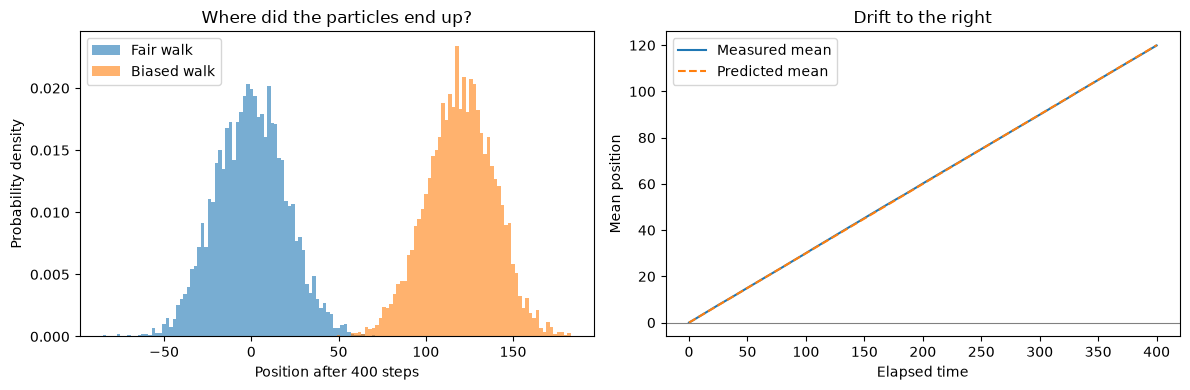

Measured mean: 119.89
Predicted mean: 120.0
Measured width: 19.51
Predicted width: 19.08


In [19]:
prob_right = 0.65
biased_positions = np.zeros(number_of_particles, dtype=float)

mean_positions = [0]
widths_biased = [0]

for time in range(1, number_of_steps + 1):
    for particle in range(number_of_particles):
        toss = np.random.random()

        if toss < prob_right:
            biased_positions[particle] += step_length
        else:
            biased_positions[particle] -= step_length

    mean_positions.append(np.mean(biased_positions))
    widths_biased.append(np.std(biased_positions))

# Calculate the predicted mean and width in physical units.
times = np.arange(number_of_steps + 1) * step_time
drift_speed = step_length * (2 * prob_right - 1) / step_time
D_biased = 2 * step_length ** 2 * prob_right * (1 - prob_right) / step_time
predicted_mean = drift_speed * times
predicted_width = np.sqrt(2 * D_biased * times)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
bins = lattice_bins(np.concatenate([positions, biased_positions]), number_of_steps)

plt.hist(positions, bins=bins, density=True,
         alpha=0.6, label='Fair walk')
plt.hist(biased_positions, bins=bins, density=True,
         alpha=0.6, label='Biased walk')

plt.xlabel('Position after ' + str(number_of_steps) + ' steps')
plt.ylabel('Probability density')
plt.title('Where did the particles end up?')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(times, mean_positions, label='Measured mean')
plt.plot(times, predicted_mean, '--', label='Predicted mean')
plt.axhline(0, color='gray', linewidth=0.8)

plt.xlabel('Elapsed time')
plt.ylabel('Mean position')
plt.title('Drift to the right')
plt.legend()

plt.tight_layout()
plt.show()

print('Measured mean:', round(np.mean(biased_positions), 2))
print('Predicted mean:', round(predicted_mean[-1], 2))
print('Measured width:', round(np.std(biased_positions), 2))
print('Predicted width:', round(predicted_width[-1], 2))

The biased cloud moves and spreads around its moving centre. For right-step probability $q$ and step length $a$, the expected increment is $a(2q-1)$, so the drift speed is $v=a(2q-1)/\Delta t_{\rm step}$. The increment variance is $4a^2q(1-q)$:

$$\langle X\rangle=vt,\qquad \mathrm{Var}(X)=2D_{\rm biased}t,\qquad D_{\rm biased}=\frac{2a^2q(1-q)}{\Delta t_{\rm step}}.$$

With the defaults ($q=0.65$, $a=\Delta t_{\rm step}=1$, 400 steps), the mean is 120 and the predicted width is $\sqrt{364}\simeq19.08$. A large-step-count continuous approximation uses $\partial_t p=-v\partial_x p+D_{\rm biased}\partial_x^2p$. Raw mean squared displacement includes drift: $\langle X^2\rangle=2D_{\rm biased}t+(vt)^2$. Measured statistics fluctuate because the ensemble is finite.

## Conclusion

Independent random steps produce a spreading particle cloud. For a fair walk, the cloud stays centred near its starting point, and its width grows approximately as $\sqrt{t}$. The particle histograms, analytic diffusion curve, and Euler grid solution agree well at later times.

Changing the probability of stepping right introduces **drift**: the centre of the cloud moves while the particles continue to spread around it. For the biased walk, both the measured mean position and width are close to their predicted values. The diffusion equation used for the fair walk describes spreading alone; a continuous model of the biased walk also needs a drift term.

The simulations use a finite number of particles taking discrete steps, so small differences from the smooth predictions are expected.

